# 📶 บทที่ 10 — Scan Strategy & Beam Geometry ร่วมกับ DEM
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และ wradlib

**ระดับ:** ขั้นสูง  |  **ต้องมีก่อน:** รันบทที่ 00 แล้ว (ใช้ DEM `wrl_dem_phk1.tif`)

**วัตถุประสงค์การเรียนรู้**
- เข้าใจ **เรขาคณิตลำบีม**: ความสูงบีมตามระยะ/มุมยก และแบบจำลอง **4/3 รัศมีโลก**
- ดึง **โปรไฟล์ภูมิประเทศ** จาก DEM ตามแนว azimuth
- สร้าง **ไดอะแกรมกลยุทธ์การกวาด (scan strategy)** แสดงความสูงบีมทุกมุมยกเทียบภูมิประเทศ
- เห็นเหตุผลของการเลือกชุดมุมยก และช่องว่างการตรวจวัดในแนวดิ่ง

---


## 🧠 หลักการเบื้องต้น

ลำบีมเรดาร์ไม่ได้พุ่งเป็นเส้นตรง แต่**โค้งตามชั้นบรรยากาศ** โดยประมาณด้วยแบบจำลอง **4/3 รัศมีโลก** (effective earth radius $k a$, โดย $k=4/3$) ความสูงศูนย์กลางลำบีมเหนือระดับน้ำทะเลที่ระยะ $r$ และมุมยก $\theta$ คือ

$$h(r,\theta) = \sqrt{\,r^2 + (k a)^2 + 2 r\,k a \sin\theta\,} - k a + h_0$$

โดย $a$ = รัศมีโลก (~6371 กม.), $h_0$ = ความสูงสถานี

- ยิ่ง**ไกล** ลำบีมยิ่ง**สูง**จากพื้น (เพราะมุมยก + ความโค้งโลก) → ที่ระยะไกลจะตรวจไม่ถึงฝนระดับต่ำ
- **ความกว้างบีม (beamwidth ~1°)** ทำให้ลำบีมกว้างขึ้นตามระยะ (ที่ 240 กม. อาจกว้างหลายกิโลเมตร)
- **กลยุทธ์การกวาด (scan strategy)** = การเลือกชุดมุมยก ให้ครอบคลุมปริมาตรบรรยากาศอย่างเหมาะสม โดยหลีกเลี่ยงการถูกภูมิประเทศบดบัง (บท 11)


## ⚙️ ส่วนหัวมาตรฐาน (ติดตั้งไลบรารี + เชื่อม Drive + ฟอนต์ไทย)


In [ ]:
%pip install -q arm_pyart wradlib rasterio pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 74.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently

In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pyart, rasterio
import warnings; warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive/tmd_radar_course'
sys.path.append(os.path.join(ROOT, '9config'))
import course_paths as P
assert os.path.exists(P.RADAR_1000), "⚠️ ไม่พบข้อมูลเรดาร์ — กรุณารัน Notebook 00 ก่อน"
assert os.path.exists(P.DEM), "⚠️ ไม่พบไฟล์ DEM — กรุณารัน Notebook 00 ก่อน"
OUT = P.results_dir('lesson10')
print("พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่:", OUT)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Mounted at /content/drive
พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson10


### 🔤 ติดตั้งฟอนต์ไทยสำหรับกราฟ (จำเป็น — มิฉะนั้นข้อความไทยจะแสดงเป็นกล่อง □□□)

ดาวน์โหลดฟอนต์ **Sarabun** (ฟอนต์ราชการไทย เหมาะงานตีพิมพ์) มาลงทะเบียนกับ matplotlib พร้อมตั้งสไตล์กราฟระดับตีพิมพ์ — รันเซลล์นี้ก่อนพลอตทุกครั้ง

In [ ]:
# ── ติดตั้ง & ตั้งค่าฟอนต์ไทยให้ matplotlib (ต้องรันก่อนพลอตกราฟที่มีข้อความไทย) ──
import os, glob, subprocess, urllib.request
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.font_manager as fm

def setup_thai_font(verbose=True):
    d = '/usr/share/fonts/truetype/sarabun'; os.makedirs(d, exist_ok=True)
    # 1) Sarabun จาก Google Fonts (ฟอนต์ราชการไทย)
    if not glob.glob(d + '/*.ttf'):
        base = 'https://github.com/google/fonts/raw/main/ofl/sarabun/'
        for fn in ('Sarabun-Regular.ttf', 'Sarabun-Bold.ttf'):
            try: urllib.request.urlretrieve(base + fn, os.path.join(d, fn))
            except Exception: pass
    # 2) สำรอง: ฟอนต์ไทย TLWG ผ่าน apt (มีใน Colab เสมอ)
    if not glob.glob(d + '/*.ttf') and not glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-thai-tlwg'], capture_output=True)
    # ลงทะเบียนฟอนต์ที่ติดตั้ง
    for fp in glob.glob(d + '/*.ttf') + glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        try: fm.fontManager.addfont(fp)
        except Exception: pass
    avail = {f.name for f in fm.fontManager.ttflist}
    chosen = next((n for n in ('Sarabun','Loma','Garuda','Norasi') if n in avail), None)
    if chosen: mpl.rcParams['font.family'] = chosen
    mpl.rcParams['axes.unicode_minus'] = False
    if verbose:
        print('ฟอนต์ไทยที่ใช้:', chosen or 'ไม่พบ — ลองรันเซลล์นี้อีกครั้งหลังติดตั้ง')
    return chosen

setup_thai_font()
# สไตล์กราฟระดับตีพิมพ์ (ฟอนต์ใหญ่ อ่านง่าย)
plt.rcParams.update({'figure.dpi':120, 'savefig.dpi':300, 'font.size':13,
    'axes.titlesize':16, 'axes.labelsize':14, 'xtick.labelsize':12,
    'ytick.labelsize':12, 'legend.fontsize':13, 'axes.unicode_minus':False})

ฟอนต์ไทยที่ใช้: Sarabun


## 1️⃣ อ่านพารามิเตอร์การกวาดจากไฟล์เรดาร์จริง

ดึงพิกัด/ความสูงสถานี, ชุดมุมยก (fixed_angle) และช่วงระยะ (range) จากไฟล์ของสถานีพิษณุโลก


In [ ]:
radar = pyart.io.read(P.RADAR_1000)
lon0 = float(radar.longitude['data'][0])
lat0 = float(radar.latitude['data'][0])
alt0 = float(radar.altitude['data'][0])
elevs = np.array([float(a) for a in radar.fixed_angle['data']])
ranges = radar.range['data'].astype(float)          # เมตร (ศูนย์กลาง gate)

print(f"สถานีพิษณุโลก: lon={lon0:.4f}, lat={lat0:.4f}, ความสูง={alt0:.0f} m")
print(f"จำนวนมุมยก {len(elevs)} ค่า: {np.round(elevs,2)} °")
print(f"ระยะสูงสุด ~{ranges.max()/1000:.0f} กม. ({len(ranges)} gate)")

สถานีพิษณุโลก: lon=100.2180, lat=16.7754, ความสูง=72 m
จำนวนมุมยก 4 ค่า: [0.48 1.48 2.39 3.39] °
ระยะสูงสุด ~240 กม. (240 gate)


## 2️⃣ ดึงโปรไฟล์ภูมิประเทศจาก DEM ตามแนว azimuth

เลือกทิศ (azimuth) หนึ่ง แล้วคำนวณตำแหน่งตามแนวรัศมีของลำบีม จากนั้นสุ่มค่าความสูงจาก DEM


โปรไฟล์ภูมิประเทศ (az=270°): สูงสุด 938 m, ต่ำสุด 6 m


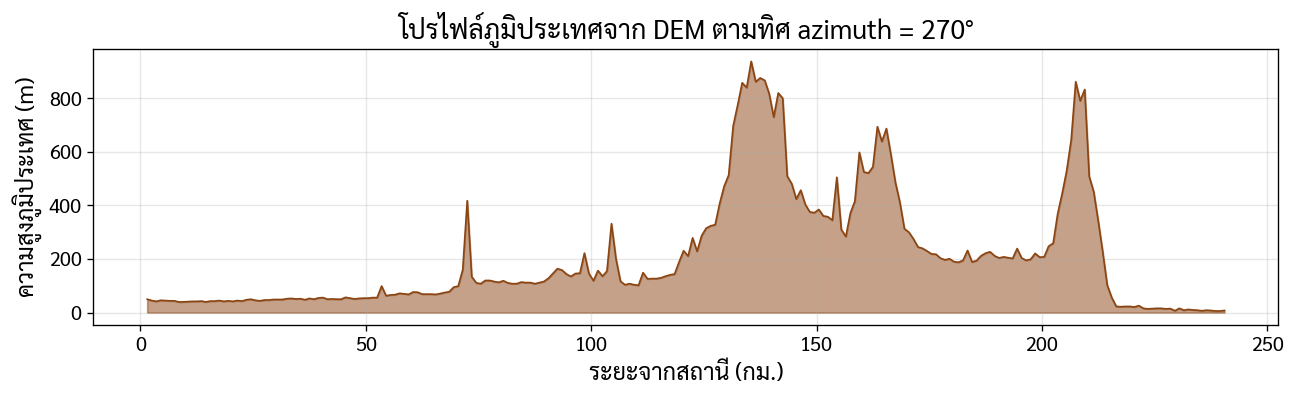

In [ ]:
from pyproj import Geod, Transformer

AZ_DEG = 270   # ทิศตะวันตก (ปรับได้ในแบบฝึกหัด — เลือกทิศที่มีภูเขา)
geod = Geod(ellps='WGS84')

# ตำแหน่ง lon/lat ตามแนวรัศมีที่แต่ละระยะ
lon_prof, lat_prof, _ = geod.fwd(np.full_like(ranges, lon0),
                                 np.full_like(ranges, lat0),
                                 np.full_like(ranges, AZ_DEG), ranges)

with rasterio.open(P.DEM) as ds:
    dem_crs = ds.crs if ds.crs else 'EPSG:4326'
    nodata = ds.nodata
    tr = Transformer.from_crs('EPSG:4326', dem_crs, always_xy=True)
    xs, ys = tr.transform(lon_prof, lat_prof)
    terrain = np.array([v[0] for v in ds.sample(np.c_[xs, ys])], dtype=float)

if nodata is not None:
    terrain[terrain == nodata] = np.nan
terrain[terrain < -1000] = np.nan
print(f"โปรไฟล์ภูมิประเทศ (az={AZ_DEG}°): สูงสุด {np.nanmax(terrain):.0f} m, ต่ำสุด {np.nanmin(terrain):.0f} m")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.fill_between(ranges/1000, terrain, color='saddlebrown', alpha=0.5)
ax.plot(ranges/1000, terrain, color='saddlebrown', lw=1)
ax.set_xlabel('ระยะจากสถานี (กม.)'); ax.set_ylabel('ความสูงภูมิประเทศ (m)')
ax.set_title(f'โปรไฟล์ภูมิประเทศจาก DEM ตามทิศ azimuth = {AZ_DEG}°')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3️⃣ ไดอะแกรม Scan Strategy ด้วย wradlib

`wradlib.vis.plot_scan_strategy` วาดความสูงลำบีมทุกมุมยกเทียบระยะ พร้อมซ้อนภูมิประเทศ


ข้าม plot_scan_strategy ของ wradlib (เวอร์ชันอาจต่างกัน): TypeError('cannot unpack non-iterable Axes object')
→ ใช้ไดอะแกรมแบบคำนวณเองในหัวข้อ 4 แทนได้เลย


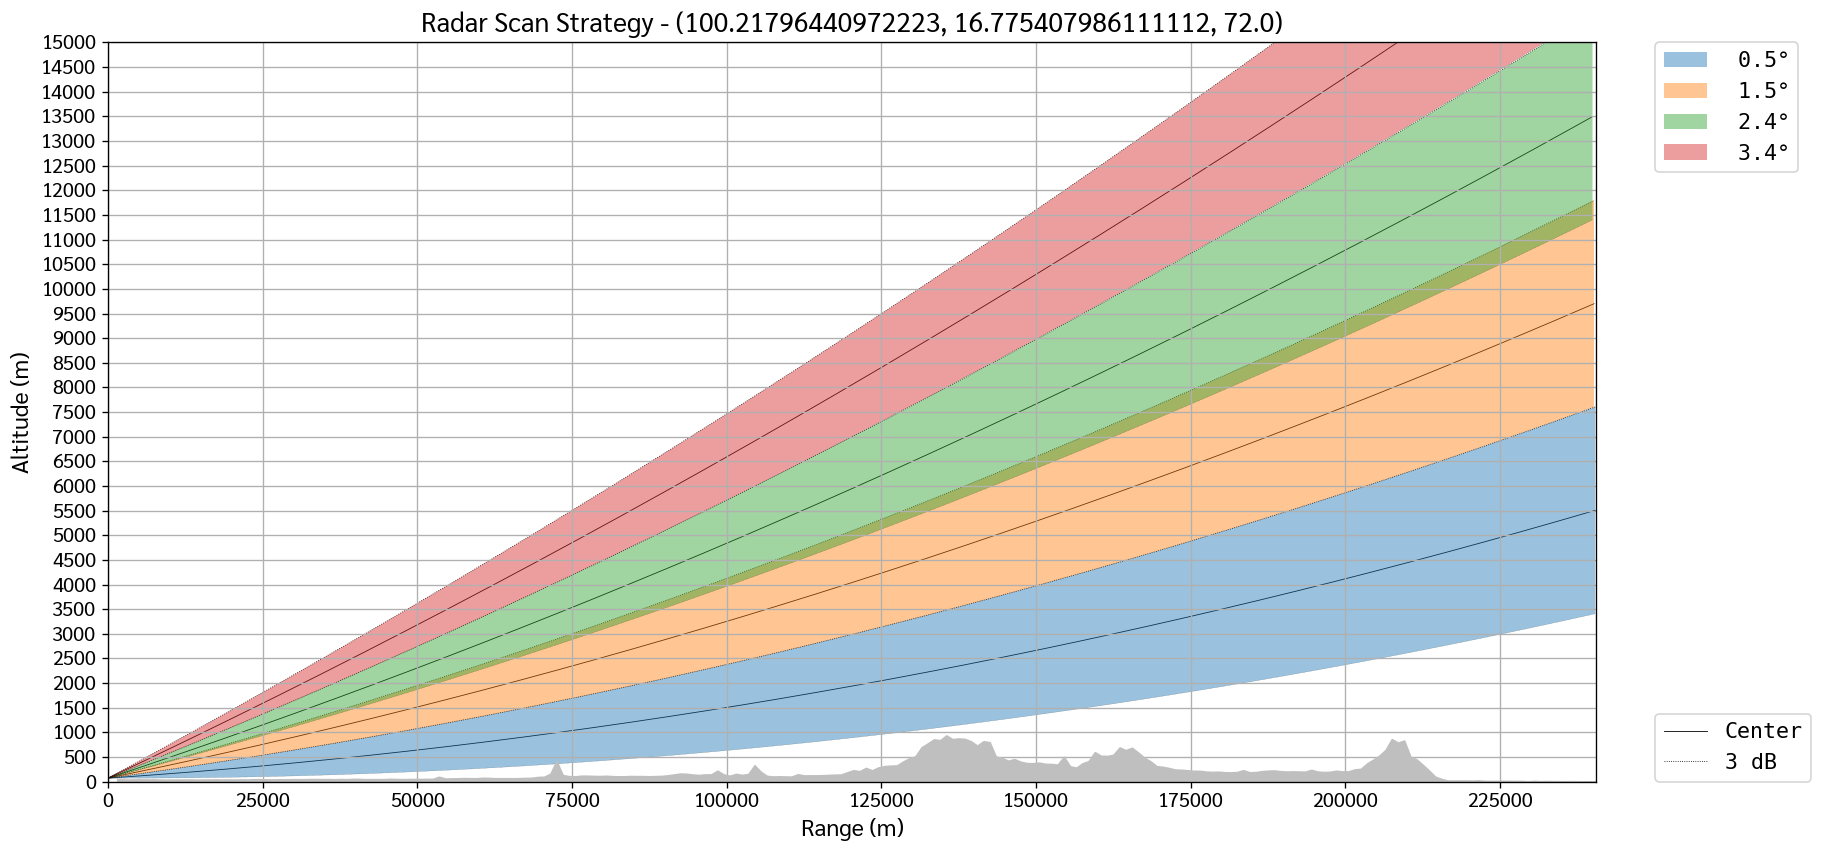

In [ ]:
try:
    import wradlib as wrl
    sitecoords = (lon0, lat0, alt0)
    ax, cbar = wrl.vis.plot_scan_strategy(
        ranges, elevs, sitecoords,
        beamwidth=1.0, vert_res=500.0, maxalt=15000.0,
        terrain=terrain, az=AZ_DEG, units='m')
    plt.gcf().set_size_inches(12, 7)
    plt.title(f'Scan strategy — สถานีพิษณุโลก (az={AZ_DEG}°)', fontsize=15)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'scan_strategy_wradlib.png'), dpi=300, bbox_inches='tight')
    plt.show()
except Exception as e:
    print("ข้าม plot_scan_strategy ของ wradlib (เวอร์ชันอาจต่างกัน):", repr(e))
    print("→ ใช้ไดอะแกรมแบบคำนวณเองในหัวข้อ 4 แทนได้เลย")

## 4️⃣ คำนวณความสูงบีมเอง (แบบจำลอง 4/3 รัศมีโลก) + ภูมิประเทศ

ไดอะแกรมนี้ควบคุมป้ายกำกับภาษาไทยได้เต็มที่ และเห็น **ช่องว่างการตรวจวัดในแนวดิ่ง** ระหว่างมุมยก


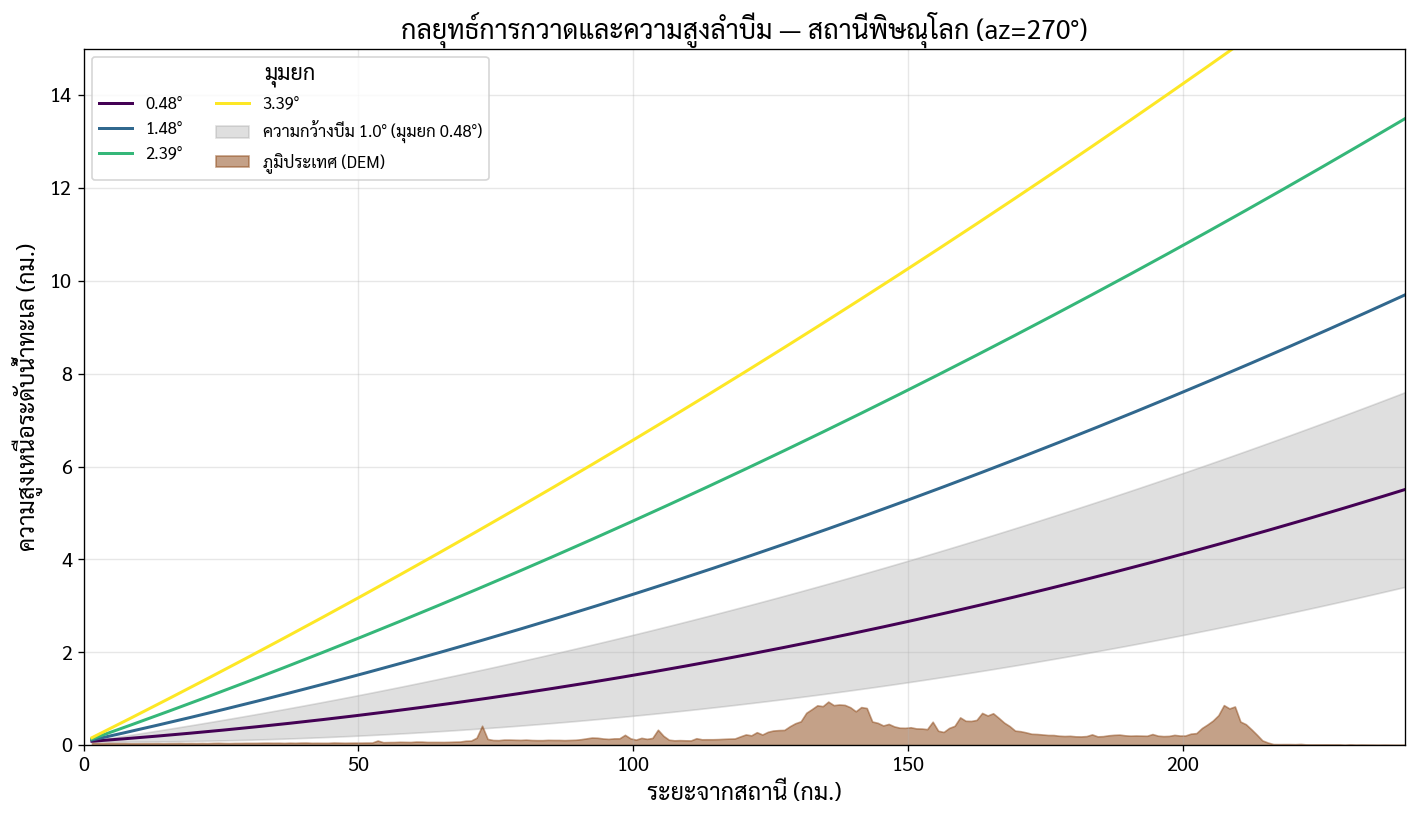

In [ ]:
A_EARTH = 6371000.0     # รัศมีโลก (m)
KE = 4.0/3.0            # effective earth radius factor
BEAMWIDTH = 1.0         # องศา

def beam_height(r, elev_deg, h0):
    "ความสูงศูนย์กลางลำบีมเหนือระดับน้ำทะเล (m) ตามแบบจำลอง 4/3 รัศมีโลก"
    th = np.radians(elev_deg)
    return np.sqrt(r**2 + (KE*A_EARTH)**2 + 2*r*KE*A_EARTH*np.sin(th)) - KE*A_EARTH + h0

fig, ax = plt.subplots(figsize=(12, 7))
cmap = plt.cm.viridis(np.linspace(0, 1, len(elevs)))
for elev, col in zip(elevs, cmap):
    h = beam_height(ranges, elev, alt0)
    ax.plot(ranges/1000, h/1000, color=col, lw=1.8, label=f'{elev:.2f}°')

# แถบความกว้างบีมของมุมยกต่ำสุด
e0 = elevs.min()
h_up = beam_height(ranges, e0 + BEAMWIDTH/2, alt0)
h_lo = beam_height(ranges, e0 - BEAMWIDTH/2, alt0)
ax.fill_between(ranges/1000, h_lo/1000, h_up/1000, color='gray', alpha=0.25,
                label=f'ความกว้างบีม {BEAMWIDTH}° (มุมยก {e0:.2f}°)')

# ภูมิประเทศ
ax.fill_between(ranges/1000, np.nan_to_num(terrain)/1000, color='saddlebrown', alpha=0.5, label='ภูมิประเทศ (DEM)')

ax.set_xlabel('ระยะจากสถานี (กม.)', fontsize=14)
ax.set_ylabel('ความสูงเหนือระดับน้ำทะเล (กม.)', fontsize=14)
ax.set_title(f'กลยุทธ์การกวาดและความสูงลำบีม — สถานีพิษณุโลก (az={AZ_DEG}°)', fontsize=16)
ax.set_ylim(0, 15); ax.set_xlim(0, ranges.max()/1000)
ax.legend(ncol=2, fontsize=10, title='มุมยก', loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'beam_height_diagram.png'), dpi=300, bbox_inches='tight')
plt.show()

**อ่านไดอะแกรม:**
- แต่ละเส้น = ศูนย์กลางลำบีมของมุมยกหนึ่ง ที่ระยะไกลลำบีมยกสูงขึ้นมาก
- **ช่องว่างระหว่างเส้น** = ปริมาตรบรรยากาศที่ไม่มีมุมยกใดตรวจถึง (โดยเฉพาะที่ระยะใกล้–สูง)
- เมื่อ**ลำบีมต่ำสุดตัดกับภูมิประเทศ** แปลว่าบีมถูกภูเขาบดบัง → นำไปสู่การวิเคราะห์ **beam blockage** ในบท 11


## 📝 แบบฝึกหัด

1. เปลี่ยน `AZ_DEG` ไปทิศอื่น (เช่น 90° ตะวันออก, 0° เหนือ) — ทิศใดมีภูเขาสูงตัดลำบีมต่ำสุดมากที่สุด?
2. สมมติเพิ่มมุมยกใหม่ (เช่น เพิ่ม 0.2° หรือ 20°) ลงใน `elevs` แล้ววาดใหม่ — ช่วยลดช่องว่างการตรวจวัดตรงไหน?
3. เปลี่ยนความสูงสถานี `alt0` (เช่น +200 m ถ้าย้ายขึ้นเนิน) แล้วดูว่าลำบีมต่ำสุดพ้นภูมิประเทศได้ดีขึ้นหรือไม่


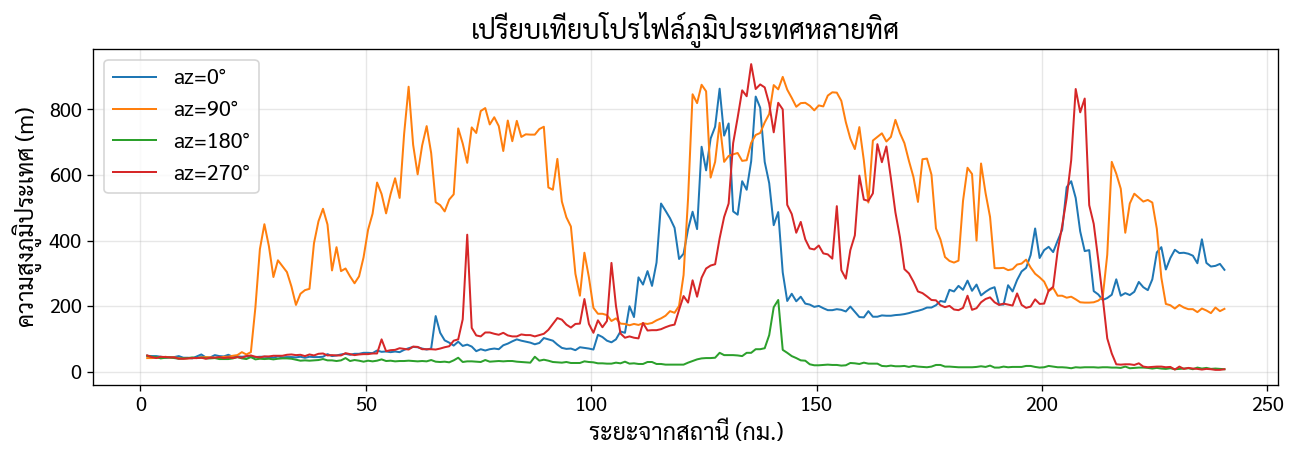

In [ ]:
# แบบฝึกหัดข้อ 1 (โครงเริ่มต้น): เทียบโปรไฟล์ภูมิประเทศหลายทิศ
fig, ax = plt.subplots(figsize=(11, 4))
for az in [0, 90, 180, 270]:
    lo, la, _ = geod.fwd(np.full_like(ranges, lon0), np.full_like(ranges, lat0),
                         np.full_like(ranges, az), ranges)
    with rasterio.open(P.DEM) as ds:
        t = Transformer.from_crs('EPSG:4326', ds.crs if ds.crs else 'EPSG:4326', always_xy=True)
        xx, yy = t.transform(lo, la)
        terr = np.array([v[0] for v in ds.sample(np.c_[xx, yy])], dtype=float)
    terr[terr < -1000] = np.nan
    ax.plot(ranges/1000, terr, lw=1.2, label=f'az={az}°')
ax.set_xlabel('ระยะจากสถานี (กม.)'); ax.set_ylabel('ความสูงภูมิประเทศ (m)')
ax.set_title('เปรียบเทียบโปรไฟล์ภูมิประเทศหลายทิศ'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
# TODO (นิสิต): ทำข้อ 2–3 ต่อ

---
## 🎯 สรุป

- ความสูงลำบีมเพิ่มตามระยะและมุมยกตามแบบจำลอง **4/3 รัศมีโลก**
- โปรไฟล์ภูมิประเทศจาก DEM ช่วยประเมินว่าลำบีมต่ำสุดถูกบดบังตรงไหน
- **กลยุทธ์การกวาด** ที่ดีต้องสมดุลระหว่างการครอบคลุมแนวดิ่งกับการเลี่ยงการบดบัง
- ไดอะแกรมนี้เป็นพื้นฐานของการวิเคราะห์ **beam blockage** เชิงปริมาณในบทที่ 11

**บทถัดไป — บทที่ 11:** Beam blockage analysis — คำนวณสัดส่วนการบดบังลำบีมด้วย DEM เชิงพื้นที่
